In [1]:
#import all labraries need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import pickle


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('MLprojectAI.csv')
df.head()

,1-What is your age group?,2-What is your current status?,3-What field do you study or work in?,4-How many hours do you spend using the internet per day?,5-What is your level of knowledge about Artificial Intelligence?,6-Do you use Artificial Intelligence tools in your study or work?,7-How often do you use AI tools per week?,8-What is your main purpose for using AI tools?,9-For which type of tasks do you usually use AI tools?,10-Which AI tools do you use most often?,11-Has Artificial Intelligence helped you save time?,12-Do you feel that AI has improved the quality of your work or studies?,13-Do you rely on AI to complete tasks entirely?,14- Do you use AI to understand difficult concepts?\n,15-Do you think AI reduces users’ critical thinking skills?,16-How much do you trust the information provided by AI tools?,17-Do you verify the information provided by AI tools?,18-Do you think AI will become essential in education and work in the future?,"20-Overall, how much do you rely on AI in your study or work?",19-How would you rate the impact of AI on your productivity?
0,2,1,1,3,3,1,2,2,1,1,2,2,1,1,1,2,2,3,1,1
1,2,1,1,4,3,1,2,1,3,1,1,1,2,2,2,2,2,3,2,2
2,2,1,1,3,2,1,2,4,3,1,1,1,3,1,2,2,1,1,2,1
3,2,3,2,3,1,1,2,3,3,1,1,1,1,3,1,1,1,1,1,2
4,2,1,2,2,1,1,1,1,2,1,1,1,3,1,1,1,1,1,1,3


In [3]:
X = df.iloc[:, :-1]   # All columns except the last one
y = df.iloc[:, -1]   # Last column (target variable)

In [4]:
feature_names = list(X.columns)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Scaling (for KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Train accuracy
train_acc_lr = lr.score(X_train, y_train)

# Test accuracy
test_acc_lr = lr.score(X_test, y_test)

print("Logistic Regression")
print("Train Accuracy:", train_acc_lr)
print("Test Accuracy:", test_acc_lr)

Logistic Regression
Train Accuracy: 0.8465909090909091
Test Accuracy: 0.8863636363636364


In [8]:
#Model 2:Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

train_acc_dt = dt.score(X_train, y_train)
test_acc_dt = dt.score(X_test, y_test)

print("Decision Tree")
print("Train Accuracy:", train_acc_dt)
print("Test Accuracy:", test_acc_dt)

Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.8409090909090909


In [9]:
#Model 3:Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

train_acc_rf = rf.score(X_train, y_train)
test_acc_rf = rf.score(X_test, y_test)

print("Random Forest")
print("Train Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)

Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.8863636363636364


In [10]:
#Model 4:KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

train_acc_knn = knn.score(X_train_scaled, y_train)
test_acc_knn = knn.score(X_test_scaled, y_test)

print("KNN")
print("Train Accuracy:", train_acc_knn)
print("Test Accuracy:", test_acc_knn)

KNN
Train Accuracy: 0.8409090909090909
Test Accuracy: 0.8636363636363636


C:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\PC\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

===== BEFORE TUNING =====
---- LR ----
Accuracy: 0.7954545454545454
F1-score: 0.5696680580401511
Precision: 0.5833333333333334
Recall: 0.559115179252479

Classification Report:

              precision    recall  f1-score   support

           1       0.85      0.89      0.87        19
           2       0.90      0.78      0.84        23
           3       0.00      0.00      0.00         2

    accuracy                           0.80        44
   macro avg       0.58      0.56      0.57        44
weighted avg       0.84      0.80      0.81        44



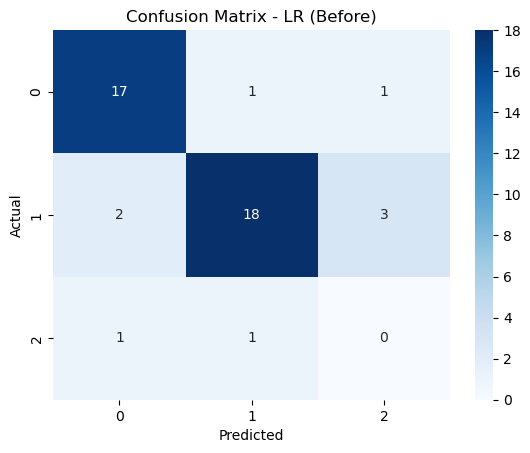

---- DT ----
Accuracy: 0.8181818181818182
F1-score: 0.561030235162374
Precision: 0.5548245614035088
Recall: 0.5675057208237986

Classification Report:

              precision    recall  f1-score   support

           1       0.79      0.79      0.79        19
           2       0.88      0.91      0.89        23
           3       0.00      0.00      0.00         2

    accuracy                           0.82        44
   macro avg       0.55      0.57      0.56        44
weighted avg       0.80      0.82      0.81        44



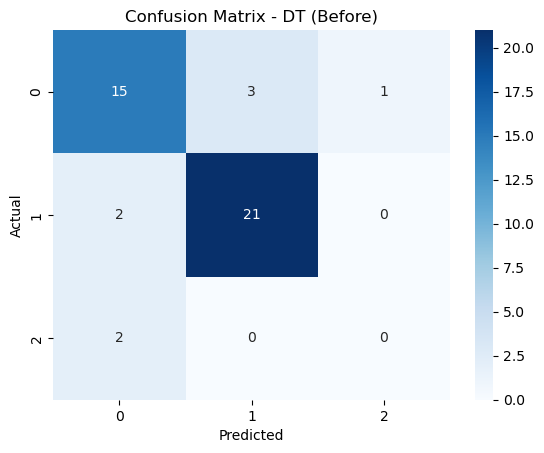

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\m

---- RF ----
Accuracy: 0.8863636363636364
F1-score: 0.6037940379403794
Precision: 0.5909090909090909
Recall: 0.620137299771167

Classification Report:

              precision    recall  f1-score   support

           1       0.82      0.95      0.88        19
           2       0.95      0.91      0.93        23
           3       0.00      0.00      0.00         2

    accuracy                           0.89        44
   macro avg       0.59      0.62      0.60        44
weighted avg       0.85      0.89      0.87        44



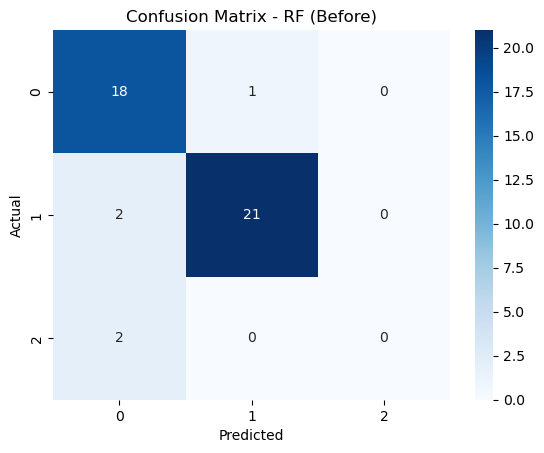

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\m

---- KNN ----
Accuracy: 0.8409090909090909
F1-score: 0.5727190605239385
Precision: 0.5606060606060606
Recall: 0.5881006864988558

Classification Report:

              precision    recall  f1-score   support

           1       0.77      0.89      0.83        19
           2       0.91      0.87      0.89        23
           3       0.00      0.00      0.00         2

    accuracy                           0.84        44
   macro avg       0.56      0.59      0.57        44
weighted avg       0.81      0.84      0.82        44



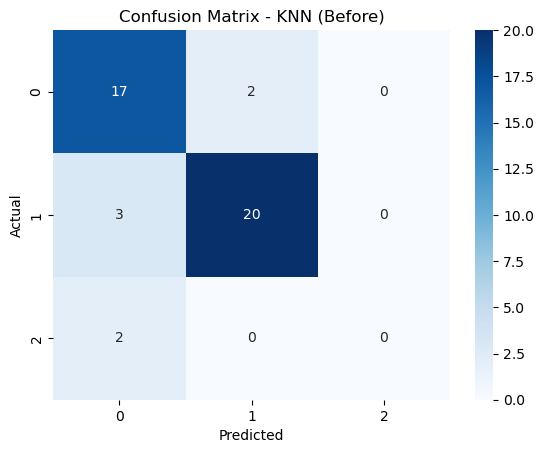

In [11]:
# 1. Base Models

models = {
    'LR': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DT': DecisionTreeClassifier(class_weight='balanced'),
    'RF': RandomForestClassifier(class_weight='balanced'),
    'KNN': KNeighborsClassifier()
}

print("===== BEFORE TUNING =====")

cv = StratifiedKFold(n_splits=5)

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    from sklearn.metrics import classification_report, precision_score, recall_score

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    print(f"---- {name} ----")
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

     # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Before)')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
   


===== AFTER TUNING =====
---- LR (Tuned) ----
Best Params: {'C': 0.1}
Accuracy: 0.7954545454545454
F1-score: 0.5752753977968176
Precision: 0.5973684210526315
Recall: 0.5560640732265446

Classification Report:

              precision    recall  f1-score   support

           1       0.84      0.84      0.84        19
           2       0.95      0.83      0.88        23
           3       0.00      0.00      0.00         2

    accuracy                           0.80        44
   macro avg       0.60      0.56      0.58        44
weighted avg       0.86      0.80      0.83        44



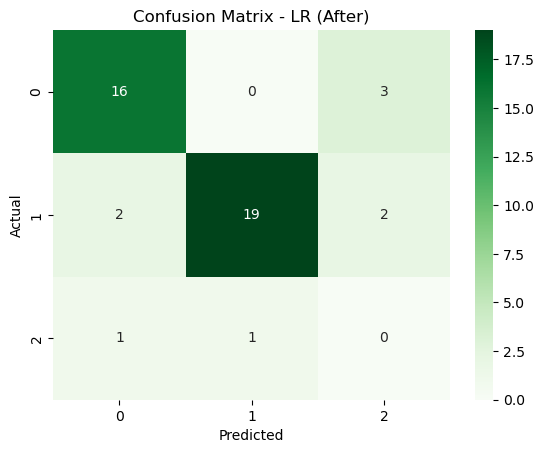

---- DT (Tuned) ----
Best Params: {'max_depth': 10, 'min_samples_split': 2}
Accuracy: 0.8181818181818182
F1-score: 0.561030235162374
Precision: 0.5548245614035088
Recall: 0.5675057208237986

Classification Report:

              precision    recall  f1-score   support

           1       0.79      0.79      0.79        19
           2       0.88      0.91      0.89        23
           3       0.00      0.00      0.00         2

    accuracy                           0.82        44
   macro avg       0.55      0.57      0.56        44
weighted avg       0.80      0.82      0.81        44



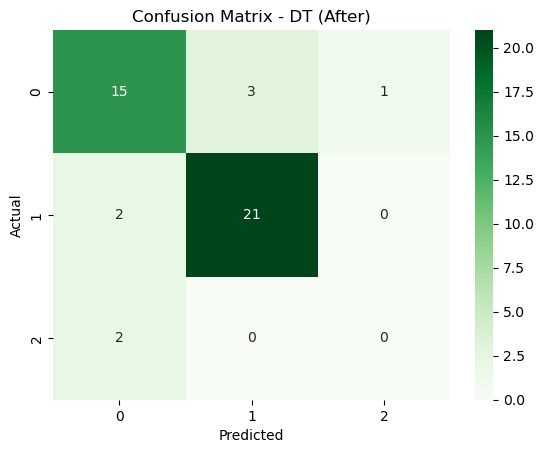

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\m

---- RF (Tuned) ----
Best Params: {'max_depth': 5, 'n_estimators': 50}
Accuracy: 0.8636363636363636
F1-score: 0.5887445887445887
Precision: 0.5783298826777088
Recall: 0.6056445461479786

Classification Report:

              precision    recall  f1-score   support

           1       0.78      0.95      0.86        19
           2       0.95      0.87      0.91        23
           3       0.00      0.00      0.00         2

    accuracy                           0.86        44
   macro avg       0.58      0.61      0.59        44
weighted avg       0.84      0.86      0.85        44



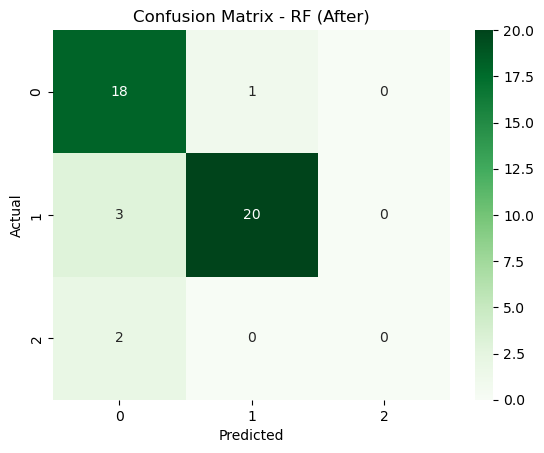

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\m

---- KNN (Tuned) ----
Best Params: {'n_neighbors': 3}
Accuracy: 0.8181818181818182
F1-score: 0.5565217391304348
Precision: 0.543823326432022
Recall: 0.570556826849733

Classification Report:

              precision    recall  f1-score   support

           1       0.76      0.84      0.80        19
           2       0.87      0.87      0.87        23
           3       0.00      0.00      0.00         2

    accuracy                           0.82        44
   macro avg       0.54      0.57      0.56        44
weighted avg       0.78      0.82      0.80        44



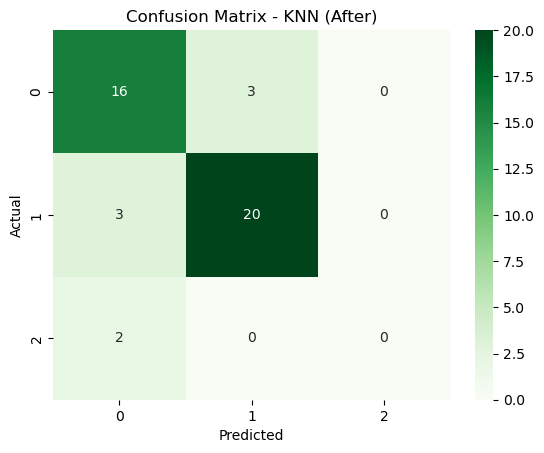

In [12]:

# 2. GridSearch (Tuning)

print("\n===== AFTER TUNING =====")

param_grids = {
    'LR': {'C': [0.1, 1, 10]},
    'DT': {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]},
    'RF': {'n_estimators': [50, 100], 'max_depth': [None, 5]},
    'KNN': {'n_neighbors': [3, 5, 7]}
}

for name, model in models.items():

    grid = GridSearchCV(model, param_grids[name], cv=cv, scoring='f1_macro')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    from sklearn.metrics import classification_report, precision_score, recall_score

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    print(f"---- {name} (Tuned) ----")
    print("Best Params:", grid.best_params_)
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix - {name} (After)')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [13]:
'''
The Random Forest model achieved the best performance with the highest accuracy and F1-score.
However, all models failed to correctly predict class 3, as shown by zero precision and recall.
This issue is due to severe class imbalance, where class 3 has very few samples.
Hyperparameter tuning did not significantly improve performance because the problem is related to data distribution rather than model configuration.'''

'\nThe Random Forest model achieved the best performance with the highest accuracy and F1-score.\nHowever, all models failed to correctly predict class 3, as shown by zero precision and recall.\nThis issue is due to severe class imbalance, where class 3 has very few samples.\nHyperparameter tuning did not significantly improve performance because the problem is related to data distribution rather than model configuration.'

In [14]:
import pickle

final_model = grid.best_estimator_

with open("model.pkl", "wb") as file:
    pickle.dump({
        "model": final_model,
        "features": feature_names
    }, file)

print("model saved correctly")

model saved correctly
